# Predicting Wine Quality: A Machine Learning Approach

<img src="https://th.bing.com/th/id/R.f8aedca66d52ac71d98286dfc3737937?rik=vK5yD8bTDc05bQ&riu=http%3a%2f%2fvinhoemprosa.com.br%2fwp-content%2fuploads%2f2023%2f06%2f10-Melhores-Vinhos-Suaves-1024x683.jpg&ehk=9TojDnpPp4RFjzTy2OX5LKyV60miWvprNQL8tcgB5YE%3d&risl=&pid=ImgRaw&r=0" width="50%">

## Problem Statement
The objective of this project is to develop a regression model that predicts the quality of red wine based on its physicochemical properties. By analyzing features such as acidity, sugar content, alcohol level, and other chemical attributes, we aim to create a predictive system that can assist winemakers and consumers in assessing wine quality objectively.



### 1.2. Type of Machine Learning Problem
This is a **regression problem** because the target variable, wine quality, is a continuous numerical value ranging from 3 to 8. Regression models predict continuous outputs, unlike classification models which predict discrete categories. Since we aim to predict the exact quality score rather than classifying wines into "good" or "bad" categories, regression is the appropriate approach.


## Dataset Description
We utilize the Wine Quality Dataset from the UCI Machine Learning Repository, specifically focusing on the red wine variant (winequality-red.csv). This dataset includes 11 physicochemical features and a quality score ranging from 3 to 8, determined by expert sensory evaluations.

## 2. Exploratory Data Analysis (EDA) - Focused

In [35]:
%matplotlib inline

import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [37]:
df = pd.read_csv('winequality-red.csv', sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


### 2.1 Distribution of the Target Variable

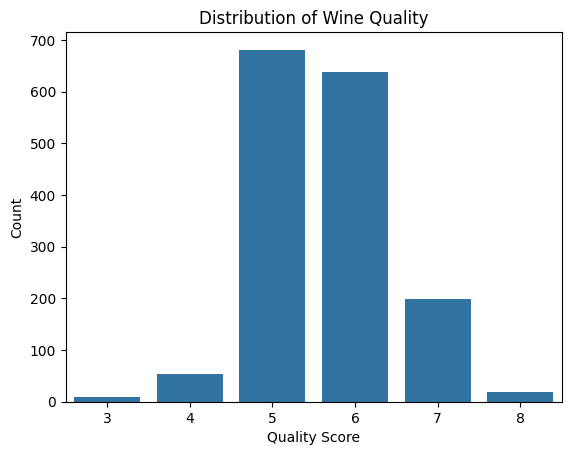

In [45]:
sns.countplot(x='quality', data=df)
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

### 2.2 Relationship with Physicochemical Features



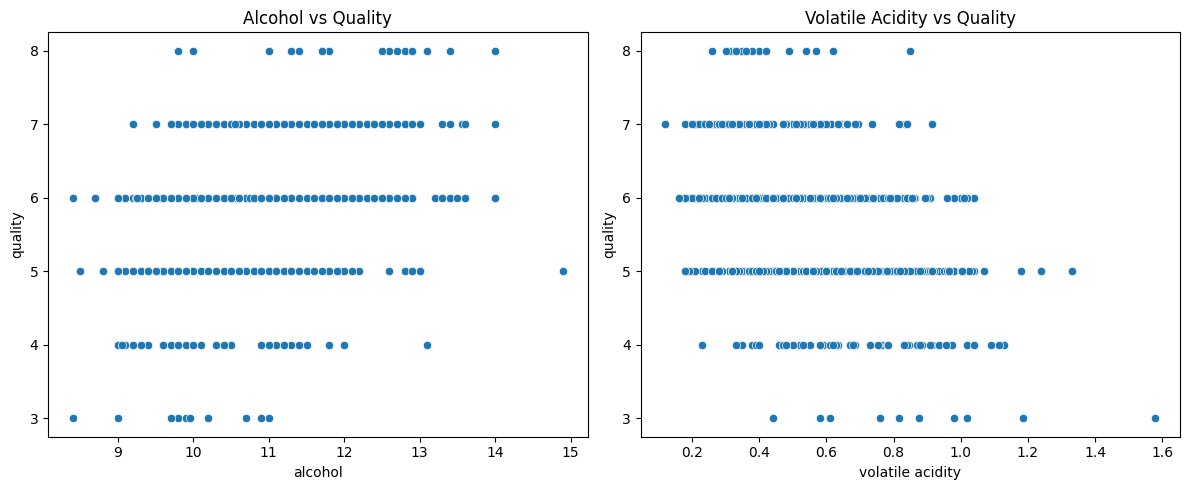

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x='alcohol', y='quality', data=df, ax=axes[0])
axes[0].set_title('Alcohol vs Quality')

sns.scatterplot(x='volatile acidity', y='quality', data=df, ax=axes[1])
axes[1].set_title('Volatile Acidity vs Quality')

plt.tight_layout()
plt.show()

We select two features: alcohol and volatile acidity.  
**1. Alcohol vs Quality**  
Alcohol content appears to have a positive relationship with wine quality. Higher-quality wines tend to show slightly higher alcohol levels, suggesting alcohol may be an important predictive feature. However, the significant variability indicates that wine quality depends on multiple factors.  

**2. Volatile Acidity vs Quality**  
Volatile acidity shows a potential negative relationship with wine quality. Higher volatile acidity values tend to be associated with lower-quality scores, suggesting it may negatively influence perceived wine quality.

**Summary:**
- Higher alcohol content tends to be associated with higher quality scores.
- Higher volatile acidity is generally linked to lower quality scores, indicating potential defects.

## 3. Preprocessing

In [26]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


There are no missing values in this dataset. If missing values were present, common strategies include:
- Mean/median imputation for numerical features.
- Dropping rows with missing values if the percentage is small.
- Using more advanced techniques like KNN imputation.

In [57]:
# Checking of the duplicated lines in the dataset
print("Number of duplicated rows:", df.duplicated().sum())
# show the duplicated rows
print("Duplicated rows:")
df[df.duplicated(keep=False)]
# Clear the duplicated rows because they can cause bias in the model
df = df.drop_duplicates()




Number of duplicated rows: 240
Duplicated rows:


In [58]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [59]:
from sklearn.preprocessing import StandardScaler

X = df.drop('quality', axis=1)
y = df['quality']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

Feature scaling is beneficial for regression models, especially linear models, as it ensures all features contribute equally to the model. We will use StandardScaler to standardize features to have a mean of 0 and a variance of 1.

## 4. Model Training and Evaluation

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [62]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f'Linear Regression - MSE: {mse_lr:.4f}, RMSE: {rmse_lr:.4f}, R²: {r2_lr:.4f}')

Linear Regression - MSE: 0.4310, RMSE: 0.6565, R²: 0.3915


The RMSE indicates the average prediction error in quality points. For example, an RMSE of 0.65 means predictions are typically off by about 0.65 quality points. The R² score shows the proportion of variance in the target variable explained by the model; a higher R² indicates better fit.

### 4.1 Comparison with Random Forest Regressor

In [63]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Random Forest - MSE: {mse_rf:.4f}, RMSE: {rmse_rf:.4f}, R²: {r2_rf:.4f}')

Random Forest - MSE: 0.3856, RMSE: 0.6210, R²: 0.4556


The Random Forest Regressor performs better than Linear Regression, with lower MSE and RMSE, and higher R², indicating it captures more complex relationships in the data.

### 4.2 Feature Importance

alcohol: 0.2813
sulphates: 0.1342
volatile acidity: 0.1139
total sulfur dioxide: 0.0775
chlorides: 0.0655
residual sugar: 0.0604
pH: 0.0565
density: 0.0564
fixed acidity: 0.0541
free sulfur dioxide: 0.0503
citric acid: 0.0498


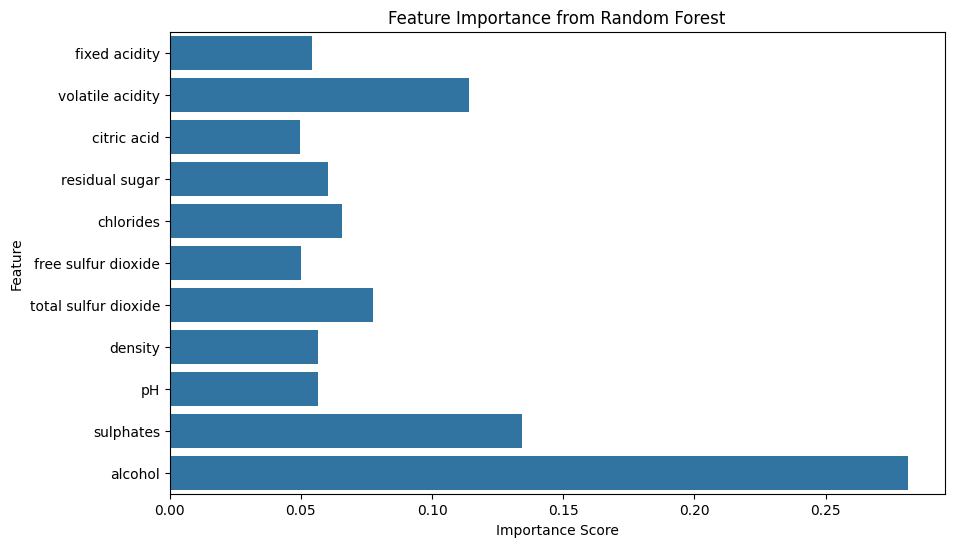

In [65]:
importances = rf.feature_importances_
feature_names = X.columns

for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f'{name}: {imp:.4f}')

    # plotting the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

The most influential features appear to be alcohol,sulfate, volatile acidity,  among others. These features have the highest importance scores, indicating they contribute most to predicting wine quality.